In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [6]:
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)

In [7]:
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [9]:
inertia = []  # WCSS (Within-Cluster Sum of Squares) values for different k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
inertia

[1000.0000000000001,
 444.8434814271495,
 223.51664545583355,
 90.20569984440866,
 78.24277344826577,
 69.56219222909496,
 58.225538418974324,
 62.37304484952667,
 52.63112825686525,
 41.8201552445673]

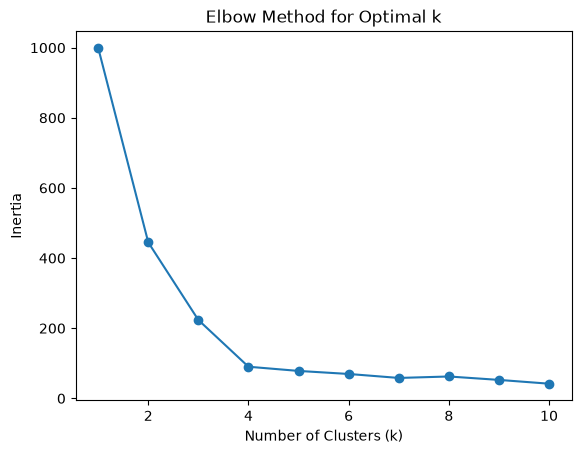

In [10]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [11]:
kmeans_final = KMeans(n_clusters=4, random_state=0)

In [12]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [13]:
df['cluster_labels'] = cluster_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

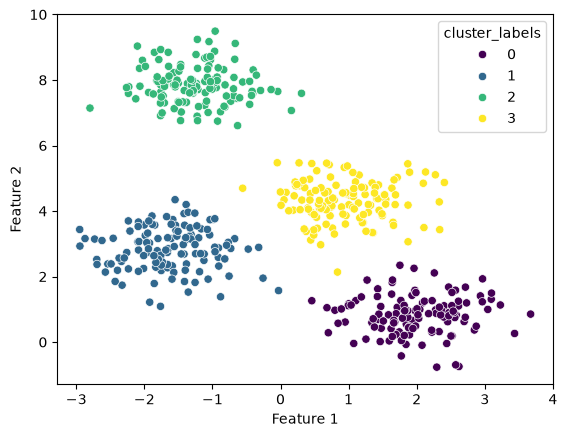

In [14]:
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='cluster_labels', palette='viridis')

In [15]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [55]:
X, y = make_moons(n_samples=500, noise=0.05, random_state=0)

In [56]:
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [58]:
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['kmeans_labels'] = kmeans_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

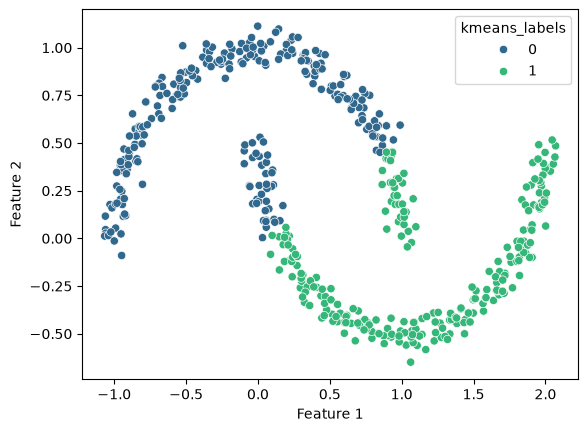

In [59]:
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='kmeans_labels', palette='viridis')

In [60]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_pred = dbscan.fit_predict(X_scaled)

In [61]:
df['dbscan_labels'] = y

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

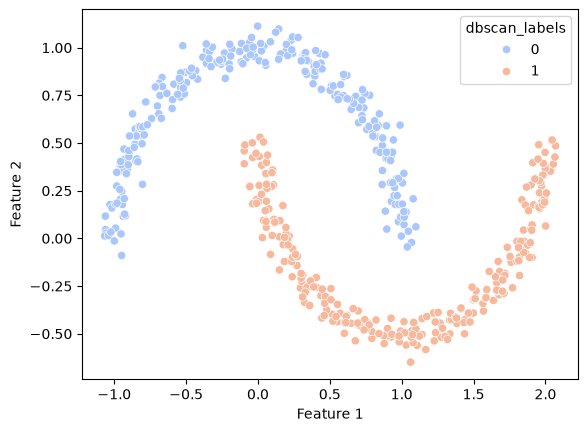

In [62]:
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='dbscan_labels', palette='coolwarm')

In [63]:
# PCA - Principal Component Analysis
from sklearn.decomposition import PCA

In [48]:
X, y = make_blobs(n_samples=500, n_features=12, centers=4, cluster_std=1.5, random_state=0)

In [52]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.20542413, -1.38307254, -0.62739414, ..., -0.74837109,
        -1.71367599,  0.43686516],
       [ 0.41273142, -0.05652129,  0.29079232, ..., -1.50711754,
         1.50081888,  0.3376856 ],
       [ 0.38165206, -0.97304388,  1.38132768, ...,  0.49425004,
        -0.59803077, -1.75434629],
       ...,
       [ 0.4741224 , -1.18930298,  1.38503186, ...,  0.50774389,
        -0.76316209, -1.13469583],
       [ 0.67120188, -0.29658404,  1.25623726, ...,  1.3197203 ,
        -0.78070506, -1.83279275],
       [ 1.11194689,  1.08615934, -1.21350176, ...,  0.27248253,
         0.07320567,  0.97850955]], shape=(500, 12))

In [50]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

In [51]:
x_pca

array([[ 2.96877164e+00, -1.93483510e+00],
       [-9.96551577e-01, -4.74697148e-01],
       [ 1.83921055e+00,  2.11006401e+00],
       [ 1.79834357e+00,  2.53810520e+00],
       [ 1.66088038e+00,  3.10290620e+00],
       [-4.54522121e-01, -4.18991106e-03],
       [ 2.40902159e+00, -2.36580021e+00],
       [ 3.03285513e+00, -1.82832868e+00],
       [ 1.06621221e+00,  2.94481065e+00],
       [-2.26197090e-01, -1.46368829e-01],
       [-3.80335955e+00, -3.43302325e-01],
       [-4.22808059e+00, -4.41550714e-01],
       [ 1.61735149e+00,  2.56044729e+00],
       [-5.94978787e-01, -2.34944874e-01],
       [-3.65467078e+00,  8.86328500e-03],
       [-2.82962102e-01,  2.60282383e-01],
       [ 2.61728119e+00, -1.69569673e+00],
       [ 2.31312732e+00,  2.49674836e+00],
       [-3.63438734e+00, -4.59917928e-01],
       [ 2.75877888e+00, -2.51053688e+00],
       [-3.15153933e+00, -7.57404143e-01],
       [-1.21937377e+00,  1.02483988e-01],
       [ 2.38877661e+00, -2.11757029e+00],
       [-3.

In [ ]:
df_pca = pd.DataFrame(x_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['cluster_labels'] = y # here we use the true labels for visualization which are known in this synthetic dataset, why do we use the true labels? Because we want to visualize how well PCA separates the clusters in 2D space.

<Axes: xlabel='Principal Component 1', ylabel='Principal Component 2'>

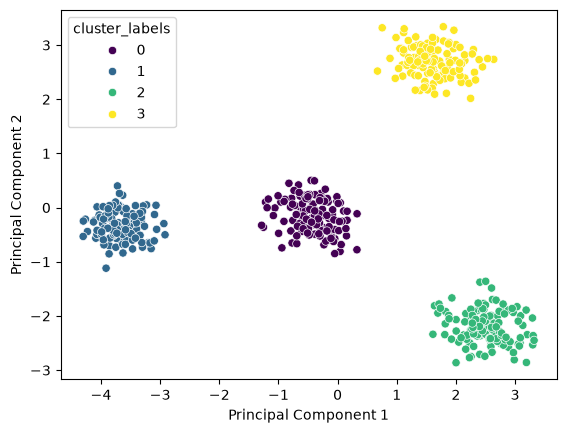

In [54]:
sns.scatterplot(data=df_pca, x='Principal Component 1', y='Principal Component 2', hue='cluster_labels', palette='viridis')